Import Libraries

In [2]:
import os
import numpy as np
import netCDF4 as nc
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers.legacy import SGD

In [3]:
#The current cell is to understand the variable name used in the .nc file

#function to load data from .nc files
def load_nc_data(file_path):
    dataset = nc.Dataset(file_path)
    
    # Check available variable names in the dataset
    print(dataset.variables.keys())
    
    # Return dataset variables
    return dataset

# Load dataset
file_path = '/Users/chiraggurumurthy/D7046E/Project/Dataset/April/T34UFA_20200401T093029_tile_3_9.nc'
dataset = load_nc_data(file_path)

dict_keys(['TCI_R', 'TCI_G', 'TCI_B', 'B04', 'B03', 'B02', 'B08', 'B05', 'B8A', 'B06', 'B11', 'B12', 'B09', 'B10', 'B01', 'Label', 'B07'])


Image shape: (512, 512, 3)
Mask shape: (512, 512)


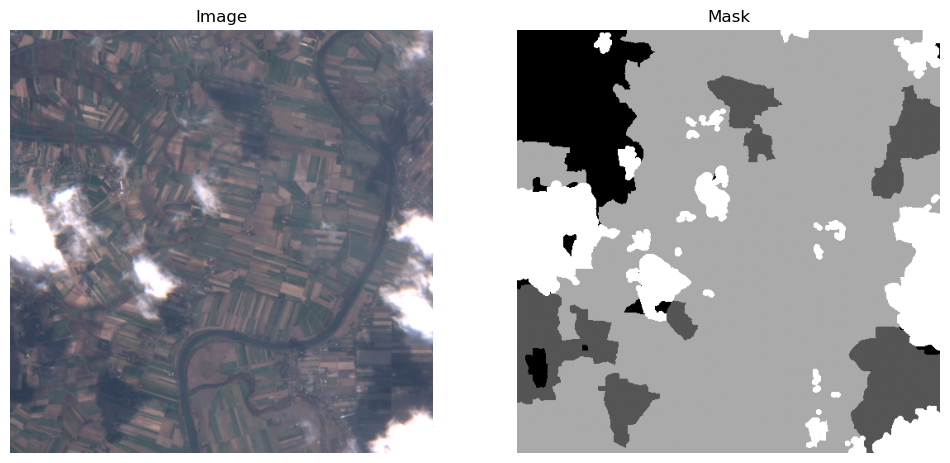

In [4]:
#The current cell is to understand the properties of one .nc file in the folder 

# List of expected variables (based on the previous cell)
expected_variables = ['TCI_R', 'TCI_G', 'TCI_B', 'B04', 'B03', 'B02', 'B08', 'B05', 'B8A', 
                      'B06', 'B11', 'B12', 'B09', 'B10', 'B01', 'Label', 'B07']

# function to load data from .nc files
def load_nc_data(file_path):
    dataset = nc.Dataset(file_path)

    #print(f'{dataset.variables}')
    
    # Check for missing variables
    missing_vars = []
    for var in expected_variables:
        if var not in dataset.variables:
            missing_vars.append(var)
    
    # If any variables are missing, print a message about the missing variables
    if missing_vars:
        print(f"Warning: Missing variables in {file_path}: {', '.join(missing_vars)}")
        return None, None  # Return None for both image and mask if data is incomplete
    
    # Load the different bands and labels
    tci_r = dataset.variables['TCI_R'][:]  # Red band
    tci_g = dataset.variables['TCI_G'][:]  # Green band
    tci_b = dataset.variables['TCI_B'][:]  # Blue band
    mask = dataset.variables['Label'][:]  # Mask data
    
    # Combine the RGB bands to form the image
    image = np.stack((tci_r, tci_g, tci_b), axis=-1)
    
    return image, mask

# Load dataset
file_path = '/Users/chiraggurumurthy/D7046E/Project/Dataset/April/T34UFA_20200401T093029_tile_3_9.nc'
image, mask = load_nc_data(file_path)

print(f'Image shape: {image.shape}')
print(f'Mask shape: {mask.shape}')

# Function to plot images and masks
def plot_sample(image, mask):
    plt.figure(figsize=(12, 6))
    
    # Plot image (color composite)
    plt.subplot(1, 2, 1)
    plt.imshow(image)  
    plt.title('Image')
    plt.axis('off')  # Hide axes for a clean view
    
    # Plot mask (binary)
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')  
    plt.title('Mask')
    plt.axis('off') 
    
    plt.show()

# Plot the first sample
plot_sample(image, mask)

Total number of images loaded: 89
Total number of masks loaded: 89


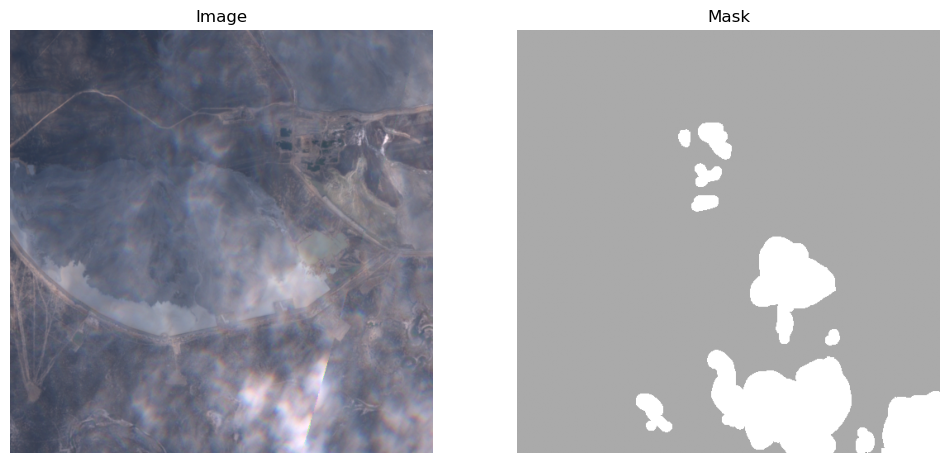

In [5]:
#The current cell will load all images into two numpy arrays 

# Function to plot images and masks
def plot_sample(image, mask, index=0):
    plt.figure(figsize=(12, 6))
    
    # Plot image (color composite)
    plt.subplot(1, 2, 1)
    plt.imshow(image[index])  
    plt.title('Image')
    plt.axis('off')  
    
    # Plot mask (binary)
    plt.subplot(1, 2, 2)
    plt.imshow(mask[index], cmap='gray')  
    plt.title('Mask')
    plt.axis('off') 
    
    plt.show()

# A function to iterate over all the .nc files from each folders 
def load_data_from_folders(base_folder):
    images = []
    masks = []
    
    month_names = ["January", "February", "March", "April", "May", "June", 
                    "July", "August", "September", "October", "November", "December"]

    for month_name in month_names:
     # Construct the folder path for each month
        month_folder = os.path.join(base_folder, month_name)
    
        if os.path.exists(month_folder):
            # Loop through all .nc files in the folder
            for filename in os.listdir(month_folder):
                if filename.endswith('.nc'):
                    file_path = os.path.join(month_folder, filename)
                    #print(f"Processing file: {file_path}")
                    
                    # Load images and masks from the .nc file
                    image, mask = load_nc_data(file_path)
                    images.append(image)
                    masks.append(mask)
                    
    #convert lists to numopy arrays
    images_array = np.array(images)
    masks_array = np.array(masks)

    return images_array, masks_array
                    
# The base folder that contains the months (January to December)
base_folder = '/Users/chiraggurumurthy/D7046E/Project/Dataset'

# Process images from all folders
images, masks = load_data_from_folders(base_folder)

# Check if images and masks have been loaded correctly
print(f"Total number of images loaded: {len(images)}")
print(f"Total number of masks loaded: {len(masks)}")

# Randomly plot an image and mask from the list 
plot_sample(images, masks, index=11)

In [6]:
#The current cell is for pre-processing the data

# Normalize the images (scale pixel values from [0, 255] to [0, 1])
images = images / 255.0

print(f'Image shape: {images.shape}')

# This step is to check if we are dealing with binary mask or multi-class mask
unique_values = np.unique(masks)
print(f"Unique values in the mask: {unique_values}")

# One-hot encode the masks to have shape (num_samples, 512, 512, num_classes)
num_classes = len(unique_values) 
masks = to_categorical(masks, num_classes=num_classes)

# Check the shape of the masks now (should be [num_samples, 512, 512, num_classes])
print(f"Shape of one-hot encoded masks: {masks.shape}")

Image shape: (89, 512, 512, 3)
Unique values in the mask: [0 1 2 3 4 5]
Shape of one-hot encoded masks: (89, 512, 512, 6)


In [7]:
#The current cell is for splitting the data into training, validation, and test sets

# Split the data into training (80%) and test (20%) sets
images_train, images_test, masks_train, masks_test = train_test_split(images, masks, test_size=0.2, random_state=42)

# Split the training data into training (80%) and validation (20%) sets
images_train, images_val, masks_train, masks_val = train_test_split(images_train, masks_train, test_size=0.2, random_state=42)

# Check the shapes of the splits
print(f"Training images shape: {images_train.shape}")
print(f"Validation images shape: {images_val.shape}")
print(f"Test images shape: {images_test.shape}")

Training images shape: (56, 512, 512, 3)
Validation images shape: (15, 512, 512, 3)
Test images shape: (18, 512, 512, 3)


In [8]:
def build_unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Encoder (downsampling)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder (upsampling)
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    # Output layer with softmax activation for multi-class segmentation
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c9)
    
    model = models.Model(inputs, outputs)
    return model

# Model parameters
input_shape = (512, 512, 3)  # Image shape
num_classes = len(unique_values)  # Number of classes in the mask

# Building the U-Net model
model = build_unet(input_shape, num_classes)

# Compile the model with appropriate loss and metrics for segmentation
optimizer = SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print a summary of the model
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 512, 512, 64  36928       ['conv2d[0][0]']                 
                                )                                                             

In [9]:
# Define the device to run the model on
device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
with tf.device(device):
    # This is to fit the model to the data
    history = model.fit(images_train, masks_train, validation_data=(images_val, masks_val), epochs=20, batch_size=16)
    pass

Epoch 1/20


2025-03-08 08:27:37.587454: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


4/4 [==============================] - 605s 146s/step - loss: 1.7901 - accuracy: 0.1473 - val_loss: 1.7603 - val_accuracy: 0.2139
Epoch 2/20
4/4 [==============================] - 571s 138s/step - loss: 1.7324 - accuracy: 0.3270 - val_loss: 1.6928 - val_accuracy: 0.2529
Epoch 3/20
4/4 [==============================] - 568s 143s/step - loss: 1.6404 - accuracy: 0.3465 - val_loss: 1.5936 - val_accuracy: 0.2155
Epoch 4/20
4/4 [==============================] - 637s 154s/step - loss: 1.5284 - accuracy: 0.2730 - val_loss: 1.5303 - val_accuracy: 0.2130
Epoch 5/20
4/4 [==============================] - 673s 165s/step - loss: 1.4204 - accuracy: 0.3309 - val_loss: 1.4111 - val_accuracy: 0.4984
Epoch 6/20
4/4 [==============================] - 579s 136s/step - loss: 1.3509 - accuracy: 0.5409 - val_loss: 1.3744 - val_accuracy: 0.4824
Epoch 7/20
4/4 [==============================] - 706s 165s/step - loss: 1.3087 - accuracy: 0.5289 - val_loss: 1.3462 - val_accuracy: 0.4773
Epoch 8/20
4/4 [========

In [10]:
#The current cell is to evaluate the model

# Evaluate the test set
test_loss, test_accuracy = model.evaluate(images_test, masks_test)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

1/1 [==============================] - 35s 35s/step - loss: 1.1663 - accuracy: 0.4506
Test Loss: 1.166282057762146, Test Accuracy: 0.4505598247051239


1/1 [==============================] - 24s 24s/step


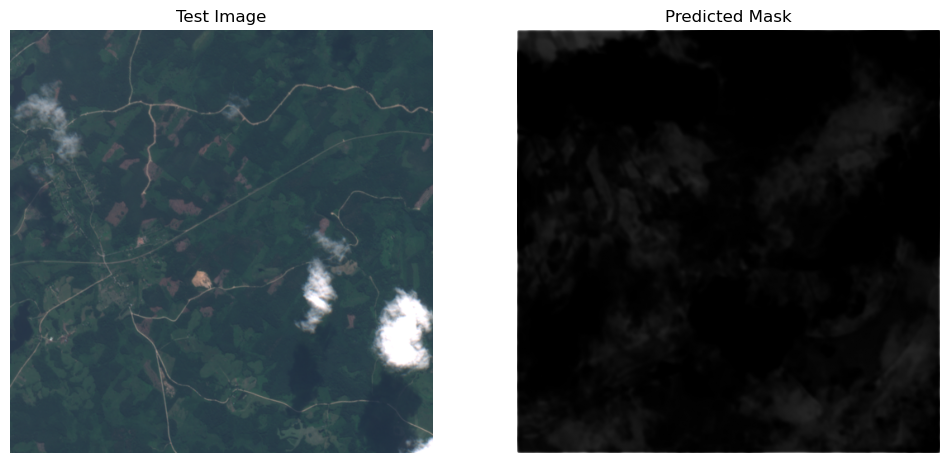

In [14]:
#The current cell is to predict and visualise the segmentation result 

# Check predictions on test images
predictions = model.predict(images_test)

# Visualise the first test image and the corresponding mask
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(images_test[4])  # Display the test image
plt.title('Test Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predictions[0, :, :, 0], cmap='gray')  # Display the predicted mask
plt.title('Predicted Mask')
plt.axis('off')

plt.show()